In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from xgboost import XGBClassifier

In [3]:

file_path = "/Users/dawson/Downloads/churn-bigml-80.csv"
df = pd.read_csv(file_path)

print(f"Dataset shape: {df.shape}")
print("\nChurn distribution:")
print(df["Churn"].value_counts())
df.head()

Dataset shape: (2666, 20)

Churn distribution:
Churn
False    2278
True      388
Name: count, dtype: int64


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [4]:
# Fix data types
df["State"] = df["State"].astype("category")
df["Area code"] = df["Area code"].astype("category")
df["International plan"] = df["International plan"].map({"Yes": 1, "No": 0})
df["Voice mail plan"] = df["Voice mail plan"].map({"Yes": 1, "No": 0})

# Feature engineering
df_fe = df.copy()
df_fe = df_fe.drop(columns=["State", "Area code"])

df_fe["total_minutes"] = (
    df_fe["Total day minutes"] +
    df_fe["Total eve minutes"] +
    df_fe["Total night minutes"] +
    df_fe["Total intl minutes"]
)

df_fe["total_charges"] = (
    df_fe["Total day charge"] +
    df_fe["Total eve charge"] +
    df_fe["Total night charge"] +
    df_fe["Total intl charge"]
)

df_fe["high_service_calls"] = (df_fe["Customer service calls"] >= 3).astype(int)
df_fe["intl_usage_ratio"] = (df_fe["Total intl minutes"] / df_fe["total_minutes"]).fillna(0)

df_fe["account_length_group"] = pd.cut(
    df_fe["Account length"],
    bins=[0, 50, 150, df_fe["Account length"].max()],
    labels=["new", "mid", "long"]
)

categorical_cols = ["International plan", "Voice mail plan", "account_length_group"]
df_fe = pd.get_dummies(df_fe, columns=categorical_cols, drop_first=True)
df_fe = df_fe.fillna(0)  # Handle any NaNs from pd.cut edge cases

# Scale numeric features
numeric_cols = df_fe.select_dtypes(include=["int64", "float64"]).columns
numeric_cols = numeric_cols.drop("Churn", errors="ignore")

scaler = StandardScaler()
df_fe[numeric_cols] = scaler.fit_transform(df_fe[numeric_cols])

X = df_fe.drop("Churn", axis=1)
y = df_fe["Churn"].astype(int)

print(f"Features shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")

Features shape: (2666, 23)
Target distribution:
Churn
0    2278
1     388
Name: count, dtype: int64


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

Training samples: 2132
Test samples: 534


In [6]:
# Build and train
xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric="logloss")
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate
print("XGBoost Results")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"F1 Score (Churn): {f1_score(y_test, y_pred_xgb):.4f}")
print()
print(classification_report(y_test, y_pred_xgb, target_names=["No Churn", "Churn"]))

XGBoost Results
Accuracy: 0.9757
F1 Score (Churn): 0.9103

              precision    recall  f1-score   support

    No Churn       0.97      1.00      0.99       455
       Churn       1.00      0.84      0.91        79

    accuracy                           0.98       534
   macro avg       0.99      0.92      0.95       534
weighted avg       0.98      0.98      0.97       534



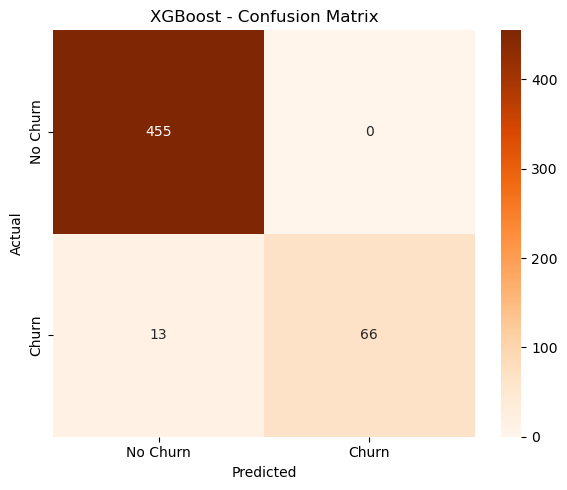

In [7]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    confusion_matrix(y_test, y_pred_xgb),
    annot=True, fmt="d", cmap="Oranges",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)
plt.title("XGBoost - Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

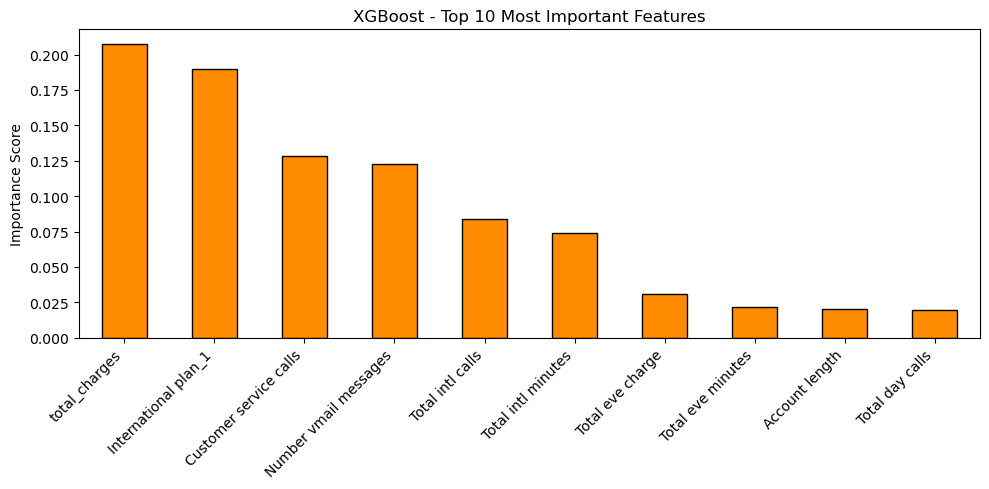


Top 10 Features:
total_charges             0.2074
International plan_1      0.1897
Customer service calls    0.1283
Number vmail messages     0.1224
Total intl calls          0.0842
Total intl minutes        0.0743
Total eve charge          0.0308
Total eve minutes         0.0215
Account length            0.0201
Total day calls           0.0193
dtype: float32


In [8]:
feat_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feat_importance.head(10).plot(kind="bar", figsize=(10, 5), color="darkorange", edgecolor="black")
plt.title("XGBoost - Top 10 Most Important Features")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("\nTop 10 Features:")
print(feat_importance.head(10).round(4))